In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,OneHotEncoder
import seaborn as sns


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
!wget https://github.com/fisher85/ml-cybersecurity/blob/master/python-web-attack-detection/datasets/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv.zip?raw=true -O dataset.zip
!unzip -u dataset.zip

zsh:1: no matches found: https://github.com/fisher85/ml-cybersecurity/blob/master/python-web-attack-detection/datasets/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv.zip?raw=true
unzip:  cannot find or open dataset.zip, dataset.zip.zip or dataset.zip.ZIP.


In [3]:
import pandas as pd

file_path = "/Users/bsharishkumar/explainable-ids-shap-lime/data/raw/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"

# Load using cp1252 / latin1 encoding
df = pd.read_csv(file_path, encoding="cp1252", low_memory=False)

# Clean column headers
df.columns = df.columns.str.strip()

# Standardize the attack labels
df["Label"] = df["Label"].str.replace("\x96", "-").str.strip()

print(df["Label"].value_counts())

Label
BENIGN                        168186
Web Attack – Brute Force        1507
Web Attack – XSS                 652
Web Attack – Sql Injection        21
Name: count, dtype: int64


<Axes: xlabel='Label'>

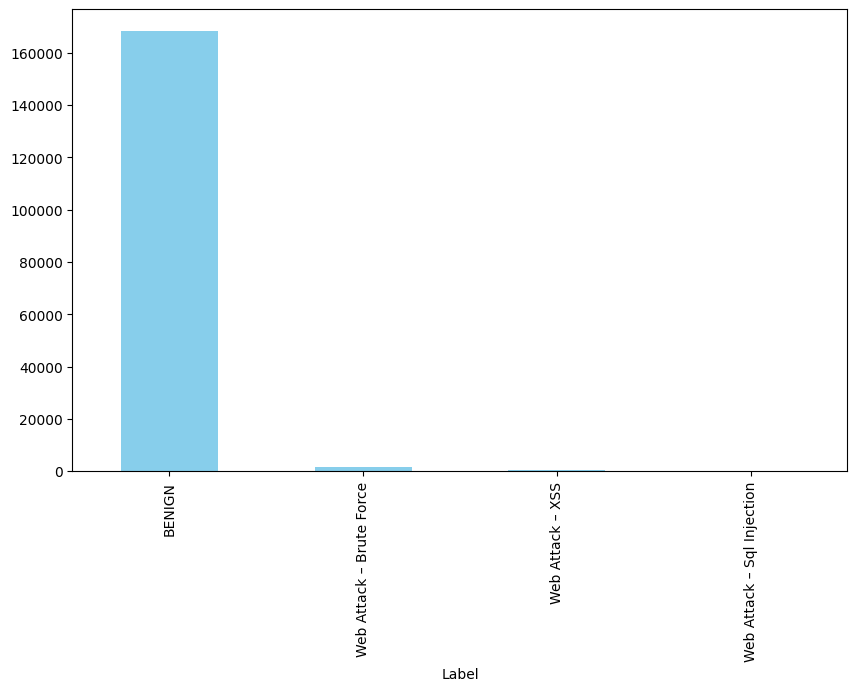

In [4]:
df['Label'].value_counts().plot(kind='bar', figsize=(10, 6), color='skyblue')

In [5]:
df.isna().sum()

Flow ID             288602
Source IP           288602
Source Port         288602
Destination IP      288602
Destination Port    288602
                     ...  
Idle Mean           288602
Idle Std            288602
Idle Max            288602
Idle Min            288602
Label               288602
Length: 85, dtype: int64

In [6]:
df.shape

(458968, 85)

In [7]:
df.columns

Index(['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
  

In [8]:
(df.isna().sum().sum())/85

288602.23529411765

In [9]:
df = df.dropna(how="all").reset_index(drop=True)
print(df.shape)              # (170366, 85)
print(df.isna().sum().sum()) # 20 — all in 'Flow Bytes/s'

(170366, 85)
20


In [10]:
df.isna().sum()

Flow ID             0
Source IP           0
Source Port         0
Destination IP      0
Destination Port    0
                   ..
Idle Mean           0
Idle Std            0
Idle Max            0
Idle Min            0
Label               0
Length: 85, dtype: int64

<Axes: xlabel='Label'>

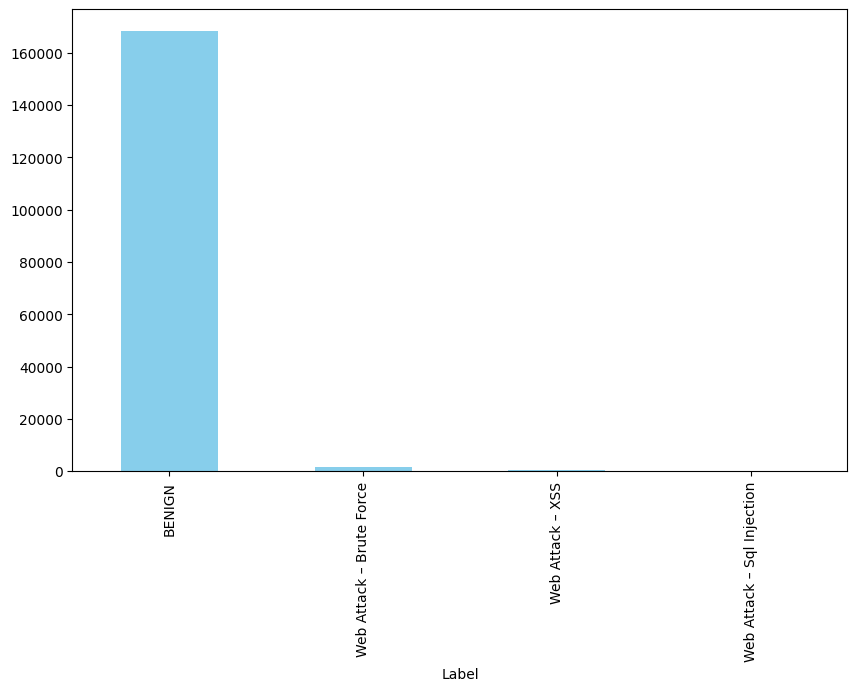

In [11]:
df['Label'].value_counts().plot(kind='bar', figsize=(10, 6), color='skyblue')

In [12]:
df=df.drop_duplicates()

In [13]:
df.shape

(170365, 85)

In [14]:
# Are the 21 SQL Injection samples truly distinct?
df[df['Label'] == 'Web Attack – Sql Injection'].describe()

# Check feature overlap between attack types
df.groupby('Label').mean(numeric_only=True)



,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Label,,,,,,,,,,,,,,,,,,,,,
BENIGN,40059.699896,7998.174736,11.343069,1.254047e+07,15.178869,18.187532,540.606772,32195.354223,169.345530,22.992128,...,12.026572,25.501311,75302.042173,47366.757351,166777.220335,50777.031828,3.738336e+06,132772.143732,3.833845e+06,3.589180e+06
Web Attack – Brute Force,47128.357001,80.000000,6.000000,6.506182e+06,12.371599,6.056403,2111.502322,3484.737226,54.505640,0.000000,...,4.851360,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
Web Attack – Sql Injection,36211.238095,80.000000,6.000000,2.870398e+06,3.047619,2.666667,316.000000,1286.285714,316.000000,0.000000,...,0.571429,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
Web Attack – XSS,50187.000000,80.000000,6.000000,6.715357e+06,7.903374,3.573620,1197.619632,4519.015337,20.197853,0.000000,...,2.486196,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00


In [15]:
# Option: merge all attacks into one "ATTACK" class for binary classification
df['Label_binary'] = df['Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK')

# Or keep multi-class but group rare ones


In [17]:
import numpy as np

# Step 1: Convert to numeric & replace Inf/-Inf with NaN
df['Flow Bytes/s'] = pd.to_numeric(df['Flow Bytes/s'], errors='coerce')
df['Flow Bytes/s'] = df['Flow Bytes/s'].replace([np.inf, -np.inf], np.nan)

# Step 2: Null out negative values (physically impossible)
df.loc[df['Flow Bytes/s'] < 0, 'Flow Bytes/s'] = np.nan

# Step 3: Fill all NaNs with median
median_val = df['Flow Bytes/s'].median()
df['Flow Bytes/s'] = df['Flow Bytes/s'].fillna(median_val)

print(f"Imputed with median: {median_val:.2f}")
print(f"Remaining NaNs: {df['Flow Bytes/s'].isna().sum()}")  # should be 0


Imputed with median: 4827.17
Remaining NaNs: 0
